** Deep Learning
1교시 - 이론 수업
2교시 - 바이너리 클래스 분류 실습
3교시 - 멀티 클래스 분류(취업 상담으로 인해 자리 비움)
4교시 - 


## 이론
- 딥러닝이란? : 신경망과 심층 신경망 (입력층, 은닉층, 출력층)

- Backpropagation (역전파) : 

    -출력층에서 입력층 방향으로 오차를 전파시키며 각 층의 가중치를 업데이트

    -오차를 각각의 가중치로 편미분하여, 가중치를 조금 바꿨을때 오차가 얼마나 변하는지 계산하는 과정

- 지도학습, 비지도 학습, 강화 학습 :

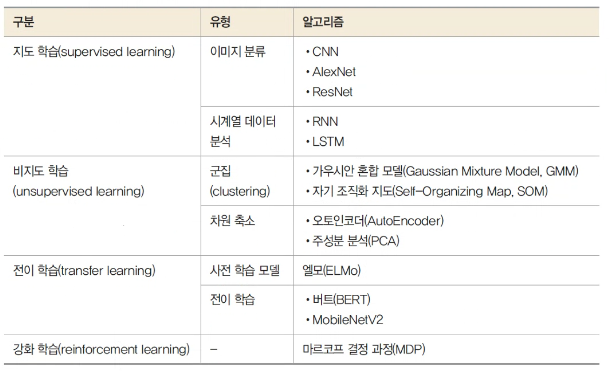
(*수업은 지도, 비지도로 나갈 예정)


- 경사하강법 같은 걸로 튜닝


- Convolution Neural Network :


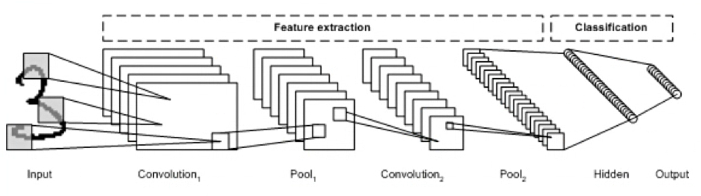


- RNN(Recurrent Neural Network) :
    -이전 데이터가 현재 데이터 처리에 영향을 미침
    -시계열 데이터, 자연어 처리 등
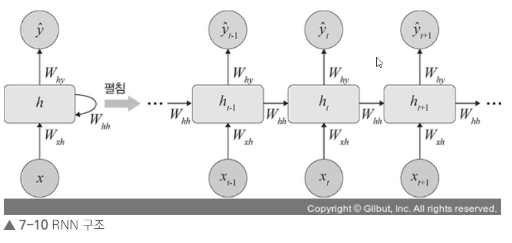



코드를 하나하나 치면서 기능 함수 설명 등 하면서 배우자고 하심.........

In [1]:
pip list #tensorflow 설치 확인 (Deeplearning frame work)

# 되어있지 않으면 설치 할 것
# !pip install tensorflow

Package                   Version
------------------------- ------------
absl-py                   2.4.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.0.5
attrs                     26.1.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
Bottleneck                1.4.2
branca                    0.8.2
brotlicffi                1.2.0.0
catboost                  1.2.10
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.4.1
cloudpickle               3.1.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.1
cycler                    0.12.1
debugpy                   1.8.16
decorator                 5.2.1
defusedxml      

In [3]:
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer      # 암진단 데이터
import joblib

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout    # 딥러닝 레이어 구성 및 드롭아웃
from tensorflow.keras.callbacks import EarlyStopping  # 학습 조기종료 콜백 함수

In [4]:
# 데이터 읽어오기
data = load_breast_cancer()
X = data.data
y = data.target

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y
print("전체 데이터 shape:", df.shape)

전체 데이터 shape: (569, 31)


In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# 딥러닝 모델 정의
model = Sequential()     # 순차형 신경망 모델 생성

model.add(Dense(64, activation='relu', input_shape=(X_test_scaled.shape[1],))) # 은닉층_1 : 64개의 노드(뉴런)
model.add(Dropout(0.2)) # 과적합 방지를 위한 노드 dropout 비율

model.add(Dense(32, activation='relu')) # 은닉층_2 : 32개의 노드(뉴런)
model.add(Dropout(0.2)) # 과적합 방지를 위한 노드 dropout 비율

model.add(Dense(1, activation='sigmoid')) # 출력층 : 0과 1로 이진분류

model.summary()

C:\Users\human3_12\anaconda3\envs\ju\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 조기 종료 콜백 정의
early_stop = EarlyStopping(monitor='val_loss', patience=10,restore_best_weights=True)

In [13]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4643 - loss: 0.7083 - val_accuracy: 0.7363 - val_loss: 0.5498
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8077 - loss: 0.5017 - val_accuracy: 0.9011 - val_loss: 0.3792
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9286 - loss: 0.3522 - val_accuracy: 0.9560 - val_loss: 0.2666
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.2557 - val_accuracy: 0.9780 - val_loss: 0.1889
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1928 - val_accuracy: 0.9780 - val_loss: 0.1385
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.1474 - val_accuracy: 0.9780 - val_loss: 0.1106
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.1173 - val_accuracy: 0.9890 - val_loss: 0.0915
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.1136 - val_accuracy: 0.9890 - 

In [14]:
# 모델 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

y_pred = (y_prob >= 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)

print('정확도: ', acc)
cm = confusion_matrix(y_test, y_pred)  # 출력에 사용되는 cm 변수 생성 정의 추가
print('confusion matrix : \n', cm)
print('분류 리포트: \n', classification_report(y_test, y_pred))

테스트 손실:  0.12248069047927856
테스트 정확도:  0.9561403393745422
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
정확도:  0.956140350877193
confusion matrix : 
 [[41  1]
 [ 4 68]]
분류 리포트: 
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [15]:
# 학습 결과 저장 (모델을 파일로 저장)

# 파일 저장
model.save('Binary_Classification.h5')

# 학습이력 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습 이력 csv로 저장
history_df.to_csv('Binary_Classification.csv', index=False)

print(' 모델 및 학습 이력 저장 완료 ')

 모델 및 학습 이력 저장 완료 


In [16]:
# 저장결과 읽어오기
loaded_model = tf.keras.models.load_model('Binary_Classification.h5')

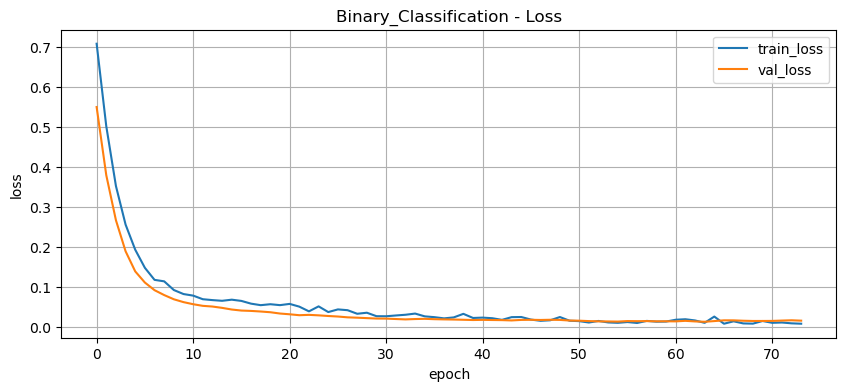

In [17]:
#  모델 성능 확인
#   loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.title('Binary_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

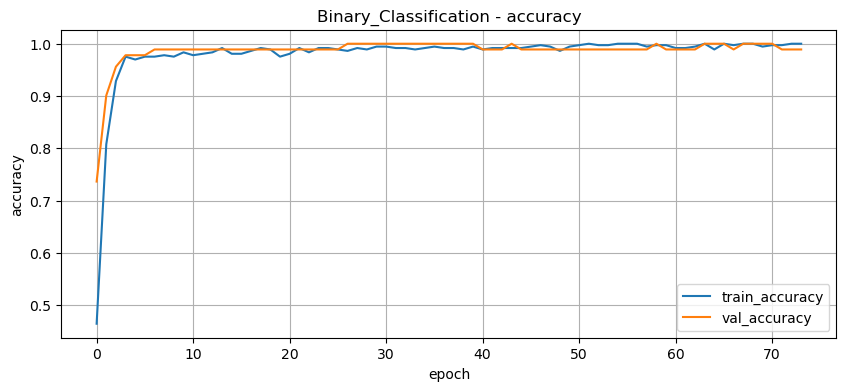

In [18]:
# accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary_Classification - accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 멀티 클래스 분류
'''
데이터 : wine dataset
클래스 : 3개
데이터 로드 > 학습 모델 설정 > 학습 > 학습 결과 저장 > 성능 확인 > 신규 데이터 예측 > 결과 시각화
'''

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine          # 와인 데이터 라이오기
import joblib                                  # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                        # 텐서플로우 Lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [22]:
# 데이터 읽어오기(와인 데이터셋)

data = load_wine()
X = data.data
y = data.target

feature_names = data.feature_names  # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y
print('전체 데이터 shape:', df.shape)

df.head()

전체 데이터 shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [23]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# one-hot 인코딩 수행 <-- 클래스 별 확률 값에서 가장 큰 값을 1로 치환하고, 나머지는 0으로 치환
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [26]:
# 모델 정의
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_test_scaled.shape[1],))) # 첫 번째 은닉층 생성
model.add(Dropout(0.2))                                                        # 과적합 방지를 위한 드롭아웃 적용

model.add(Dense(32, activation='relu')) # 두 번째 은닉층 추가

model.add(Dense(3, activation='softmax')) # 출력층은 클래스 3개 활성화 함수는 softmax

model.summary()

C:\Users\human3_12\anaconda3\envs\ju\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 모델 컴파일 설정
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 설정
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [28]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3717 - loss: 1.0803 - val_accuracy: 0.6897 - val_loss: 0.8919
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7611 - loss: 0.8560 - val_accuracy: 0.8276 - val_loss: 0.7357
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8584 - loss: 0.7026 - val_accuracy: 0.9310 - val_loss: 0.6103
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9381 - loss: 0.5683 - val_accuracy: 0.9310 - val_loss: 0.5012
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9646 - loss: 0.4609 - val_accuracy: 0.9655 - val_loss: 0.4079
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9735 - loss: 0.3808 - val_accuracy: 0.9655 - val_loss: 0.3279
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9735 - loss: 0.3023 - val_accuracy: 0.9655 - val_loss: 0.2623
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.2333 - val_accuracy: 0.9655 - val_loss:

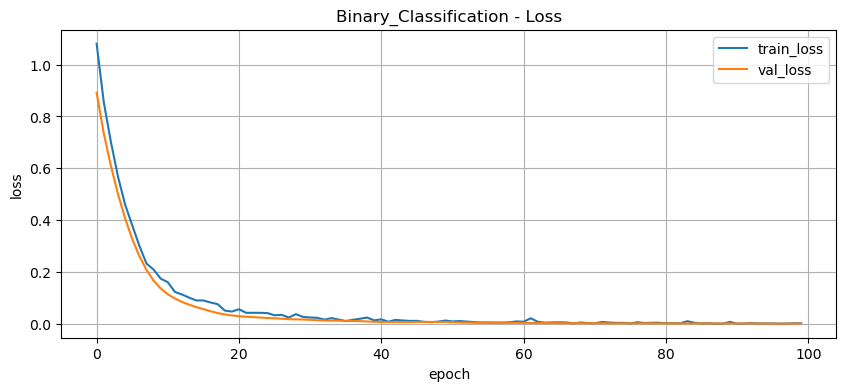

In [29]:
# loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# 모델 평가 : 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측확률
y_prob = model.predict(X_test_scaled)

# 가장 높은 확률이 높은 클래스를 선택
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# CM 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도:', acc)
print('confusion matrix: \n', cm)
print('분류 리포트 : \n', classification_report(y_test, y_pred))

테스트 손실:  0.03673086687922478
테스트 정확도:  1.0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
정확도: 1.0
confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [31]:
# 학습 결과 저장

# 모델을 파일로 저장
model.save('./results/multiclass_model.h5')

# 스케일러 저장
joblib.dump(scaler, './results/multiclass_model.pkl')

# 학습이력 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력 저장
history_df.to_csv('./results/multiclass_model.csv', index=False)

print("저장 완료")

저장 완료


In [32]:
# 저장 결과 읽어오기
loaded_model = tf.keras.models.load_model('./results/multiclass_model.h5')

loaded_scaler = joblib.load('./results/multiclass_model.pkl')

In [33]:
# 신규 데이터 예측 (추론)
new_data = X_test[:5]
new_data_scaled = loaded_scaler.transform(new_data)
new_prob = loaded_model.predict(new_data_scaled)
new_pred = np.argmax(new_prob, axis=1)
# 신규 데이터 5행을 가져왔고, (x 데이터)
# 학습 데이터와 스케일을 맞췄고
# 학습 결과 기반으로 신규데이터에 대해 예측 수행
# x에 해당하는 클래스 별 확률 계산 (a 30%, b 10% c 60%)
# softmax 확률 가장 높은 값을 결과로 반환

# 예측 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측클래스: {new_pred[i]}, 클래스 별 확률: {new_prob[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9999988e-01 1.3808926e-07 4.9358775e-08]
2번 샘플 - 예측클래스: 2, 클래스 별 확률: [0.00186799 0.45309213 0.5450399 ]
3번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9997854e-01 1.3677478e-05 7.7854002e-06]
4번 샘플 - 예측클래스: 1, 클래스 별 확률: [7.8525366e-03 9.9180108e-01 3.4633453e-04]
5번 샘플 - 예측클래스: 1, 클래스 별 확률: [5.9665152e-04 9.9930108e-01 1.0223374e-04]


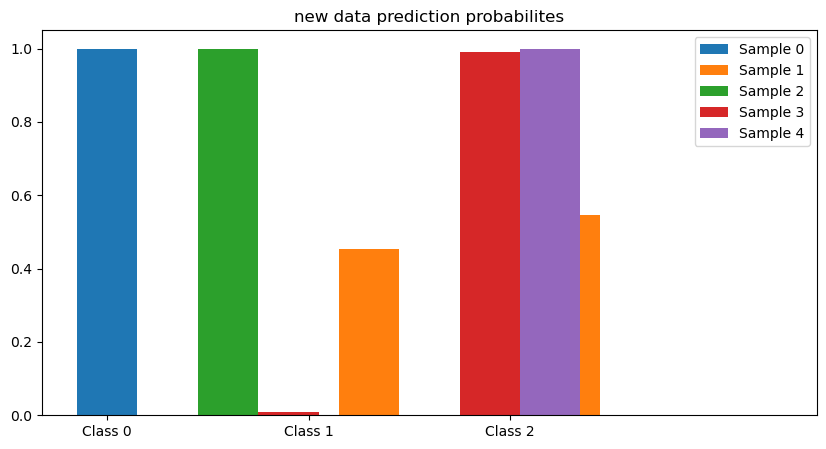

In [34]:
plt.figure(figsize=(10,5))
for i in range(len(new_prob)):
    plt.bar(
        np.arange(3) + i*0.3,
        new_prob[i],
        width=0.3,
        label=f"Sample {i}"
    )
plt.xticks([0,1,2], ['Class 0', 'Class 1', 'Class 2'])
plt.title('new data prediction probabilites')
plt.legend()
plt.show()

## CNN 이미지 분류
옷 구분 하는 이미지 분류 모델

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  # import 중복 제거
from sklearn.preprocessing import StandardScaler      # import 중복 제거
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc # import 중복 제거
from sklearn.datasets import load_wine                 # 와인 데이터 읽어오기
import joblib                                          # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                                # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal',
    'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('X_train shape : ', X_train.shape)
print('X_test shape : ', X_test.shape)

X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [3]:
# # 픽셀값 0~1 범위로 정규화
# 원본 이미지의 오타(X_test / 255.0)를 X_train / 255.0으로 수정했습니다.
X_train = X_train / 255.0
X_test = X_test / 255.0

# cnn 입력 형태에 맞게 채널 차원을 reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 모델 정의
model = Sequential()     # 순차형 신경망 생성

# 첫번째 합성곱(convolution layer) 층을 추가
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
# 풀링층 추가
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# 두번째 합성곱(convolution layer) 층을 추가
model.add(Conv2D(64, (3,3), activation='relu'))
# 풀링층 추가
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# 1차원 벡터로 펼침
model.add(Flatten())

C:\Users\human3_12\anaconda3\envs\ju\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# 완전 연결층 추가
model.add(Dense(128, activation = 'relu'))

# dropout 추가
model.add(Dropout(0.3))

# 출력층
model.add(Dense(10, activation = 'softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 설정
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [15]:
# 모델 학습
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 모델 평가
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

Epoch 1/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9309 - loss: 0.2107 - val_accuracy: 0.9014 - val_loss: 0.3129
Epoch 2/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9312 - loss: 0.2092 - val_accuracy: 0.9003 - val_loss: 0.3229
Epoch 3/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9343 - loss: 0.2006 - val_accuracy: 0.9046 - val_loss: 0.3157
Epoch 4/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9362 - loss: 0.1911 - val_accuracy: 0.9048 - val_loss: 0.3051
Epoch 5/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9370 - loss: 0.1931 - val_accuracy: 0.9025 - val_loss: 0.3117
Epoch 6/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9402 - loss: 0.1840 - val_accuracy: 0.9055 - val_loss: 0.3115
Epoch 7/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9420 - loss: 0.1788 - val_accuracy: 0.9065 - val_loss: 0.3125
Epoch 8/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9446 - loss: 0.1759 - val

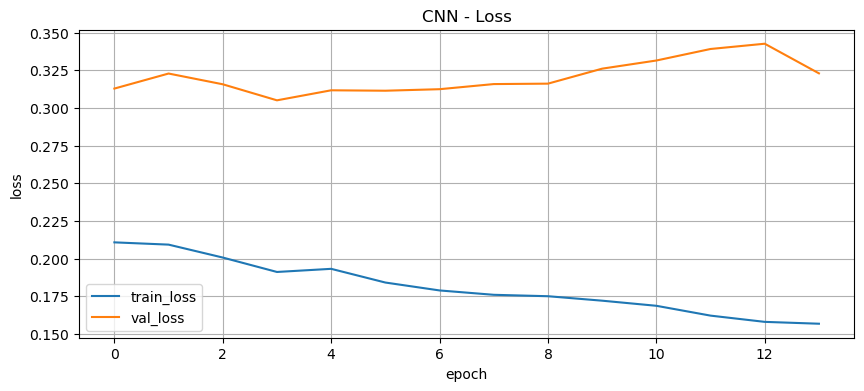

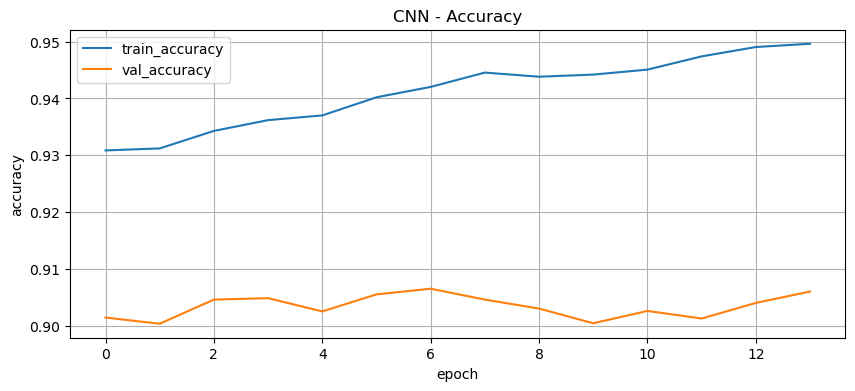

In [16]:
# 결과 시각화 - Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)  # 그래프를 격자로 표시
plt.show()

# 결과 시각화 - Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy') 
plt.title('CNN - Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# 모델 성능 평가
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("테스트 손실", test_loss)
print("테스트 정확도", test_acc)

테스트 손실 0.31841814517974854
테스트 정확도 0.9027000069618225


In [18]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [19]:
# 학습 결과 저장

model.save('./results/cnn_fashion_mnist.h5')

In [20]:
# 읽어오기
loaded_model = tf.keras.models.load_model('./results/cnn_fashion_mnist.h5')

# 신규 데이터 예측/분류
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측 결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 샘플 - 예측클래스: {class_names[new_pred[i]]}, 클래스 별 확률: {new_prob[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1번 샘플 - 예측클래스: Ankle boot, 클래스 별 확률: [4.2745505e-09 3.0517754e-08 9.2267708e-13 2.2616416e-11 1.2880916e-11
 1.8953660e-04 1.0144054e-07 3.7458597e-03 7.9454610e-11 9.9606448e-01]
2번 샘플 - 예측클래스: Pullover, 클래스 별 확률: [2.1302807e-03 1.0489423e-12 9.8454314e-01 2.2897227e-06 8.1919134e-04
 5.7506915e-09 1.1078973e-02 1.2522174e-08 1.4260676e-03 4.6319587e-11]
3번 샘플 - 예측클래스: Trouser, 클래스 별 확률: [2.6930138e-04 9.9933028e-01 9.8816129e-11 3.9892524e-04 2.6556629e-10
 1.2176843e-14 1.4970794e-06 2.0157690e-17 3.1608331e-13 2.7114015e-13]
4번 샘플 - 예측클래스: Trouser, 클래스 별 확률: [2.6928957e-04 9.9933028e-01 9.8824234e-11 3.9901544e-04 2.6563871e-10
 1.2176704e-14 1.4971108e-06 2.0157382e-17 3.1607066e-13 2.7115932e-13]
5번 샘플 - 예측클래스: Shirt, 클래스 별 확률: [1.6903013e-01 1.6482327e-05 3.8153064e-02 5.2686986e-03 3.3754900e-03
 5.4291679e-05 7.8085548e-01 1.4562633e-05 3.2283247e-03 3.4617726e-06]


()

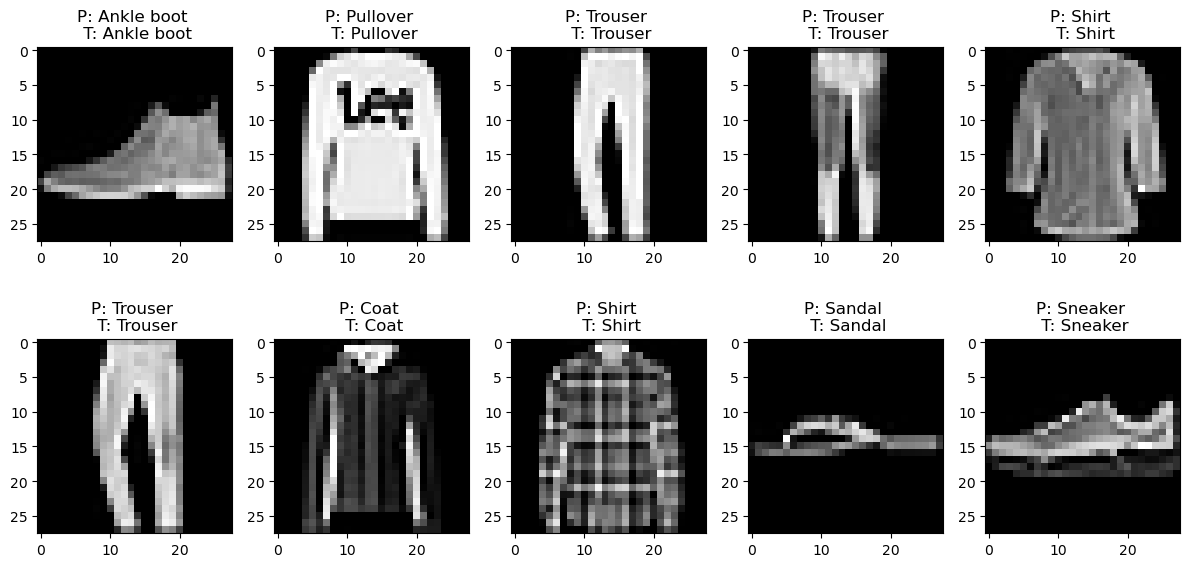

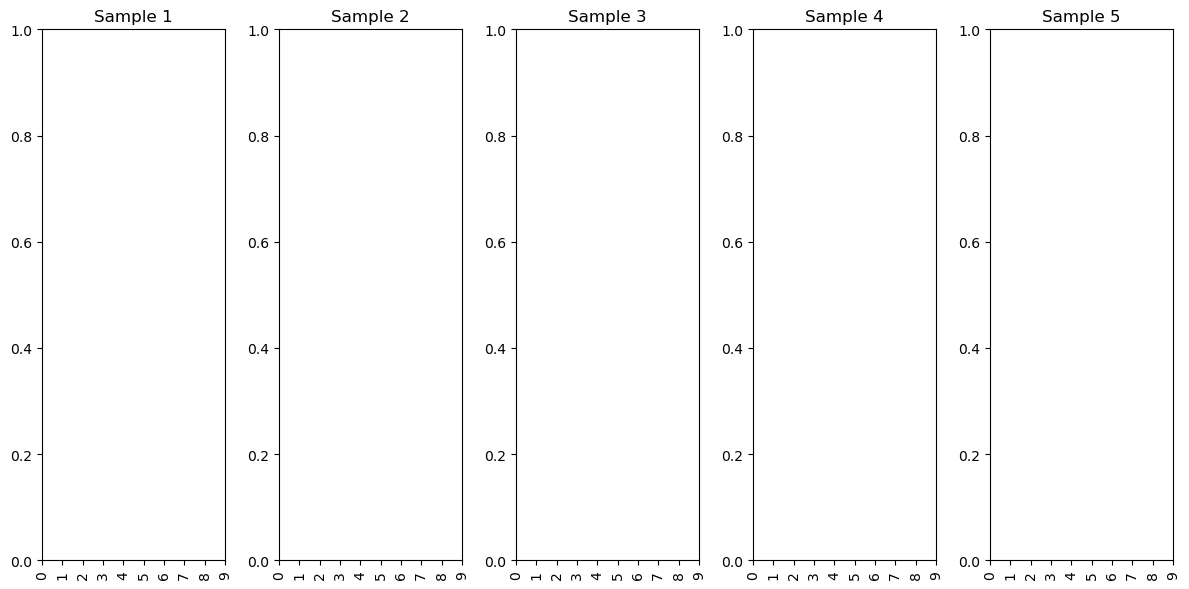

In [21]:
# 예측 결과 시각화 --> 테스트 이미지 10개와 예측 결과 시각화
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i]]} \n T: {class_names[y_test[i]]}")

plt.tight_layout()
()

# 신규 이미지 5개에 대한 확률 분포
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    (range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
()

X_train shape : (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 8, 8, 128)           │              

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 127ms/step - accuracy: 0.4527 - loss: 1.5390 - val_accuracy: 0.5626 - val_loss: 1.2024
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6208 - loss: 1.0562 - val_accuracy: 0.6259 - val_loss: 1.0224
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.6850 - loss: 0.8896 - val_accuracy: 0.6022 - val_loss: 1.1819
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.7229 - loss: 0.7895 - val_accuracy: 0.6327 - val_loss: 1.0589
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.7454 - loss: 0.7202 - val_accuracy: 0.6472 - val_loss: 1.0651
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.7716 - loss: 0.6580 - val_accuracy: 0.7371 - val_loss: 0.7489
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.7826 - loss: 0.6147 - val_accuracy: 0.7247 - val_loss: 0.8162
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.8003 - loss: 0

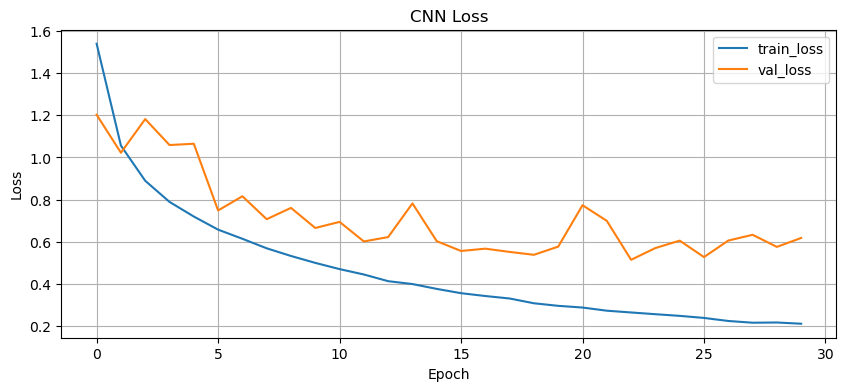

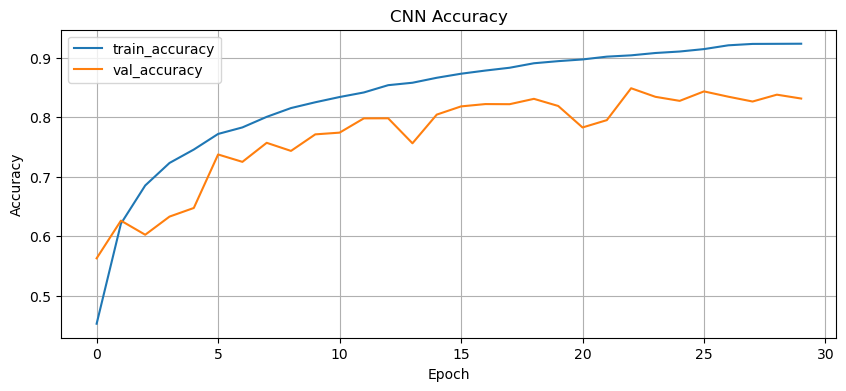

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1번 샘플 | 실제: cat | 예측: cat
2번 샘플 | 실제: ship | 예측: ship
3번 샘플 | 실제: ship | 예측: ship
4번 샘플 | 실제: airplane | 예측: airplane
5번 샘플 | 실제: frog | 예측: frog


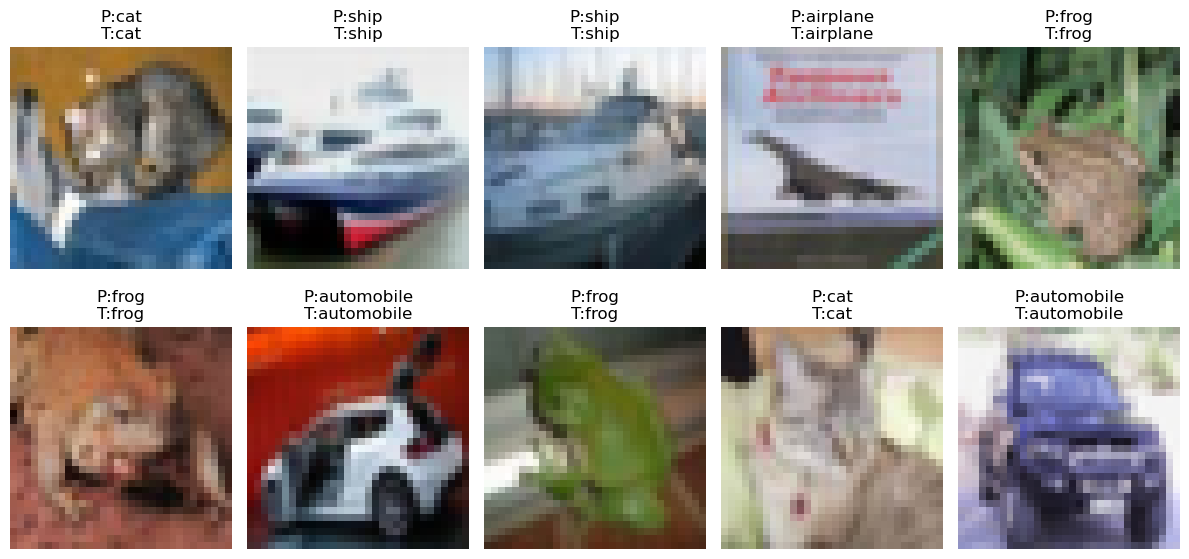

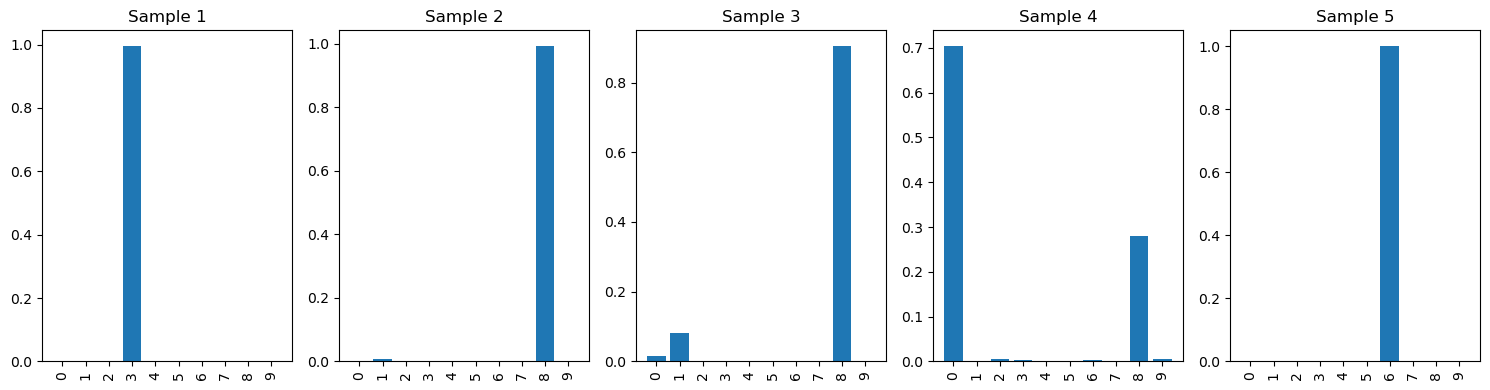

In [26]:
## CIFAR10에 적용해보기 => 미안합니다. 이건 내가 알아서 한 코드고 강사님 코드는 나랑 달라서... 깃헙에 코드 올라오면 그걸로 해...

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation
)
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------
# 랜덤 시드 고정
# ---------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------
# CIFAR-10 데이터 로드 (32*32 이미지)
# ---------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 클래스 이름
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

# ---------------------------------------------------
# 정규화
# ---------------------------------------------------
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# (50000,1) -> (50000,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# ---------------------------------------------------
# CNN 모델 생성
# ---------------------------------------------------
model = Sequential()

# Block 1
model.add(
    Conv2D(
        32,
        (3,3),
        padding='same',
        input_shape=(32,32,3)
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(
    Conv2D(
        32,
        (3,3),
        padding='same'
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


# Block 2
model.add(
    Conv2D(
        64,
        (3,3),
        padding='same'
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(
    Conv2D(
        64,
        (3,3),
        padding='same'
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


# Block 3
model.add(
    Conv2D(
        128,
        (3,3),
        padding='same'
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(
    Conv2D(
        128,
        (3,3),
        padding='same'
    )
)
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


# Fully Connected
model.add(Flatten())

model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# ---------------------------------------------------
# 모델 구조 확인
# ---------------------------------------------------
model.summary()

# ---------------------------------------------------
# 컴파일
# ---------------------------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------
# Early Stopping
# ---------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ---------------------------------------------------
# 학습
# ---------------------------------------------------
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------
# 평가
# ---------------------------------------------------
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n테스트 손실 :", test_loss)
print("테스트 정확도 :", test_acc)

# ---------------------------------------------------
# Loss 그래프
# ---------------------------------------------------
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

# ---------------------------------------------------
# Accuracy 그래프
# ---------------------------------------------------
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()

plt.show()

# ---------------------------------------------------
# 모델 저장
# ---------------------------------------------------
model.save("cnn_cifar10.h5")

# ---------------------------------------------------
# 예측
# ---------------------------------------------------
y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

# ---------------------------------------------------
# 모델 불러오기
# ---------------------------------------------------
loaded_model = tf.keras.models.load_model(
    "cnn_cifar10.h5"
)

# ---------------------------------------------------
# 신규 데이터 예측
# ---------------------------------------------------
new_images = X_test[:5]

new_prob = loaded_model.predict(new_images)

new_pred = np.argmax(new_prob, axis=1)

# ---------------------------------------------------
# 예측 결과 출력
# ---------------------------------------------------
for i in range(5):

    print(
        f"{i+1}번 샘플"
        f" | 실제: {class_names[y_test[i]]}"
        f" | 예측: {class_names[new_pred[i]]}"
    )

# ---------------------------------------------------
# 이미지 10개 시각화
# ---------------------------------------------------
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"P:{class_names[y_pred[i]]}\n"
        f"T:{class_names[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 확률 분포 시각화
# ---------------------------------------------------
plt.figure(figsize=(15,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.bar(range(10), new_prob[i])

    plt.xticks(
        range(10),
        rotation=90
    )

    plt.title(
        f"Sample {i+1}"
    )

plt.tight_layout()
plt.show()